# VNI Data Cleaning and Forecasting

This notebook is a VNI-focused version of `clean_data.ipynb`. It loads `VNI.csv`, cleans numeric columns, and builds ARIMA/Prophet forecasts on the Close series.

In [1]:
import pandas as pd
from datetime import datetime
import time
import vnstock

def fetch_vnindex_nested(start_date_str):
    mkt = vnstock.Market()
    overall_start = pd.to_datetime(start_date_str)
    final_end = datetime.now()
    
    all_data = [] # Chứa toàn bộ dữ liệu từ 2007 đến nay
    
    print(f"Bắt đầu crawl dữ liệu từ {start_date_str} đến nay...")
    
    current_macro_start = overall_start
    
    # --- VÒNG LẶP NGOÀI (MACRO): CHIA CHU KỲ 2 NĂM ---
    while current_macro_start <= final_end:
        # Cộng 2 năm, trừ 1 ngày
        macro_end = current_macro_start + pd.DateOffset(years=2) - pd.Timedelta(days=1)
        if macro_end > final_end:
            macro_end = final_end
            
        print("\n" + "="*60)
        print(f"BẮT ĐẦU CHU KỲ: {current_macro_start.strftime('%Y-%m')} ĐẾN {macro_end.strftime('%Y-%m')}")
        print("="*60)
        
        current_micro_start = current_macro_start
        macro_chunks = [] # Chứa dữ liệu của riêng chu kỳ 2 năm hiện tại
        
        # --- VÒNG LẶP TRONG (MICRO): CHIA NHỎ 150 NGÀY ---
        while current_micro_start <= macro_end:
            micro_end = current_micro_start + pd.Timedelta(days=130)
            if micro_end > macro_end:
                micro_end = macro_end
                
            str_start = current_micro_start.strftime("%Y-%m-%d")
            str_end = micro_end.strftime("%Y-%m-%d")
            
            print(f"[{datetime.now().strftime('%H:%M:%S')}] {str_start} -> {str_end}", end=" ")
            
            try:
                # Gọi API
                df_chunk = mkt.index("VNINDEX").ohlcv(start=str_start, end=str_end)
                
                if df_chunk is not None and not df_chunk.empty:
                    macro_chunks.append(df_chunk)
                    print(f"-> OK ({len(df_chunk)} dòng)")
                else:
                    print("-> Trống")
                    
            except Exception as e:
                print(f"-> LỖI: {e}")
                
            # Tịnh tiến cho vòng lặp nhỏ tiếp theo
            current_micro_start = micro_end + pd.Timedelta(days=1)
            
            # Nghỉ ngơi 2s để tôn trọng giới hạn 20 request/phút
            if current_micro_start <= final_end:
                time.sleep(2)
                
        # --- KẾT THÚC VÒNG LẶP TRONG CỦA 1 CHU KỲ ---
        if macro_chunks:
            macro_df = pd.concat(macro_chunks)
            all_data.append(macro_df)
            print(f">>> Hoàn thành chu kỳ. Thu được tổng: {len(macro_df)} dòng.")
        
        if macro_end <= final_end:
            time.sleep(90)
        # Tịnh tiến sang chu kỳ 2 năm tiếp theo
        current_macro_start = macro_end + pd.Timedelta(days=1)
        
    # --- GỘP TOÀN BỘ DỮ LIỆU CUỐI CÙNG ---
    if all_data:
        print("\n" + "*"*60)
        print("ĐANG GỘP VÀ LÀM SẠCH TOÀN BỘ DỮ LIỆU LỊCH SỬ...")
        final_df = pd.concat(all_data)
        
        # Lọc trùng lặp tại các điểm nối và sắp xếp thời gian
        final_df = final_df.drop_duplicates(subset=['time'], keep='first')
        final_df = final_df.sort_values(by='time')
        final_df = final_df.reset_index(drop=True)
        
        print(f"HOÀN THÀNH XUẤT SẮC! Tổng số dòng VNI: {len(final_df)}")
        return final_df
    else:
        print("Không tải được dữ liệu.")
        return pd.DataFrame()

# --- Chạy thực tế ---
# Kéo từ 2007
vnindex_history = fetch_vnindex_nested("2007-01-01")

if not vnindex_history.empty:
    vnindex_history.to_csv("VNINDEX_Full_History.csv", index=False)
    print("Đã xuất file: VNINDEX_Full_History.csv")

Bắt đầu crawl dữ liệu từ 2022-01-01 đến nay...

BẮT ĐẦU CHU KỲ: 2022-01 ĐẾN 2023-12
[13:53:12] 2022-01-01 -> 2022-05-11 

-> OK (84 dòng)
[13:53:20] 2022-05-12 -> 2022-09-19 -> OK (91 dòng)
[13:53:22] 2022-09-20 -> 2023-01-28 -> OK (88 dòng)
[13:53:25] 2023-01-29 -> 2023-06-08 -> OK (91 dòng)
[13:53:28] 2023-06-09 -> 2023-10-17 -> OK (91 dòng)
[13:53:31] 2023-10-18 -> 2023-12-31 -> OK (53 dòng)
>>> Hoàn thành chu kỳ. Thu được tổng: 498 dòng.

BẮT ĐẦU CHU KỲ: 2024-01 ĐẾN 2025-12
[13:55:05] 2024-01-01 -> 2024-05-10 -> OK (85 dòng)
[13:55:07] 2024-05-11 -> 2024-09-18 -> OK (91 dòng)
[13:55:10] 2024-09-19 -> 2025-01-27 -> OK (91 dòng)
[13:55:14] 2025-01-28 -> 2025-06-07 -> OK (86 dòng)
[13:55:17] 2025-06-08 -> 2025-10-16 -> OK (92 dòng)
[13:55:20] 2025-10-17 -> 2025-12-31 -> OK (54 dòng)
>>> Hoàn thành chu kỳ. Thu được tổng: 499 dòng.

BẮT ĐẦU CHU KỲ: 2026-01 ĐẾN 2026-05
[13:56:52] 2026-01-01 -> 2026-05-11 -> OK (83 dòng)
[13:56:56] 2026-05-12 -> 2026-05-13 -> OK (2 dòng)
>>> Hoàn thành chu kỳ. Thu được tổng: 85 dòng.

************************************************************
ĐANG GỘP VÀ LÀM SẠCH TOÀN BỘ D

In [1]:
# Install only if needed in your current kernel
# %pip install pandas numpy matplotlib statsmodels scikit-learn prophet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [8]:
df = pd.read_csv(
r"C:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\VNI.csv",
sep=";",
thousands=","
)

# Drop trailing empty column if present from CSV export
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


df = df.sort_values('Date').dropna(subset=['Close']).reset_index(drop=True)
def parse_volume(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)

    text = str(value).strip().replace(',', '')
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}

    suffix = text[-1].upper() if text else ''
    if suffix in multipliers:
        number_part = pd.to_numeric(text[:-1], errors='coerce')
        return number_part * multipliers[suffix] if not pd.isna(number_part) else np.nan

    return pd.to_numeric(text, errors='coerce')
df['Date'] = pd.to_datetime(df['Date'])
df['Volume'] = df['Volume'].apply(parse_volume)
print('Shape:', df.shape)
display(df.head())
display(df.tail())

Shape: (4808, 6)


,Date,Open,High,Low,Close,Volume
0,2007-01-02,751.04,751.04,741.27,741.27,6350.0
1,2007-01-03,745.13,757.71,745.13,757.71,5930.0
2,2007-01-04,784.45,788.82,784.45,788.82,10800.0
3,2007-01-05,818.04,818.04,816.51,816.51,11080.0
4,2007-01-08,840.22,840.22,825.11,825.11,11610.0


,Date,Open,High,Low,Close,Volume
4803,2026-04-15,1775.65,1801.89,1775.39,1800.65,805510000.0
4804,2026-04-16,1800.65,1824.03,1795.42,1819.83,819390000.0
4805,2026-04-17,1819.83,1846.19,1812.24,1817.17,632350000.0
4806,2026-04-20,1813.42,1838.74,1802.42,1832.81,690090000.0
4807,2026-04-21,1823.24,1866.10,1823.24,1847.05,608830000.0



=== Descriptive Statistics: VNI Close Price ===

                     Value
Mean          8.349008e+02
Median        7.784850e+02
Maximum       1.902930e+03
Minimum       2.355000e+02
Std. dev.     3.660167e+02
Skewness      5.459018e-01
Kurtosis     -5.772777e-01
Jarque-Bera   3.055654e+02
Probability   4.439350e-67
Sum           4.014203e+06
Sum Sq. dev.  6.439853e+08
Observations  4.808000e+03


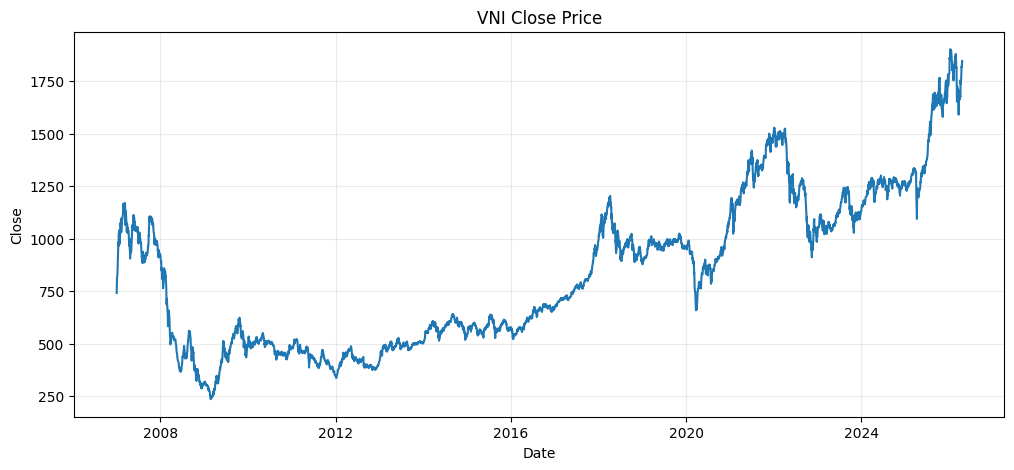

In [27]:
from scipy import stats

# Compute comprehensive descriptive statistics for Close price
close_price = df['Close'].astype(float).dropna()

# Jarque-Bera test
jb_stat, jb_pval = stats.jarque_bera(close_price)

stats_dict = {
    'Mean': [close_price.mean()],
    'Median': [close_price.median()],
    'Maximum': [close_price.max()],
    'Minimum': [close_price.min()],
    'Std. dev.': [close_price.std()],
    'Skewness': [stats.skew(close_price)],
    'Kurtosis': [stats.kurtosis(close_price)],
    'Jarque-Bera': [jb_stat],
    'Probability': [jb_pval],
    'Sum': [close_price.sum()],
    'Sum Sq. dev.': [((close_price - close_price.mean()) ** 2).sum()],
    'Observations': [len(close_price)]
}

# Create DataFrame
stats_table = pd.DataFrame(stats_dict).T
stats_table.columns = ['Value']
print('\n=== Descriptive Statistics: VNI Close Price ===\n')
print(stats_table)

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='tab:blue', linewidth=1.5)
plt.title('VNI Close Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_close_price.png', dpi=300, bbox_inches='tight')
plt.show()



=== Descriptive Statistics: First-Differenced VNI Close Price ===

                      Value
Mean               0.230035
Median             0.700000
Maximum           79.010000
Minimum         -115.050000
Std. dev.         11.778707
Skewness          -0.923215
Kurtosis           8.511156
Jarque-Bera    15191.939748
Probability        0.000000
Sum             1105.780000
Sum Sq. dev.  666774.491694
Observations    4807.000000


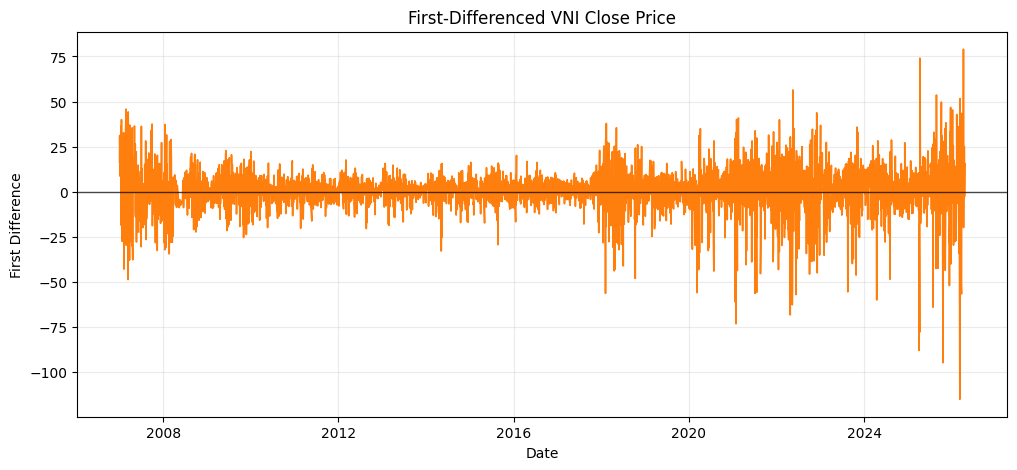

In [28]:
from scipy import stats

# First-difference the Close price series
close_price_diff = df['Close'].astype(float).dropna().diff().dropna()

# Jarque-Bera test on the differenced series
jb_stat_diff, jb_pval_diff = stats.jarque_bera(close_price_diff)

diff_stats_dict = {
    'Mean': [close_price_diff.mean()],
    'Median': [close_price_diff.median()],
    'Maximum': [close_price_diff.max()],
    'Minimum': [close_price_diff.min()],
    'Std. dev.': [close_price_diff.std()],
    'Skewness': [stats.skew(close_price_diff)],
    'Kurtosis': [stats.kurtosis(close_price_diff)],
    'Jarque-Bera': [jb_stat_diff],
    'Probability': [jb_pval_diff],
    'Sum': [close_price_diff.sum()],
    'Sum Sq. dev.': [((close_price_diff - close_price_diff.mean()) ** 2).sum()],
    'Observations': [len(close_price_diff)]
}

# Print descriptive statistics table
diff_stats_table = pd.DataFrame(diff_stats_dict).T
diff_stats_table.columns = ['Value']
print('\n=== Descriptive Statistics: First-Differenced VNI Close Price ===\n')
print(diff_stats_table)

# Plot the differenced series
plt.figure(figsize=(12, 5))
plt.plot(df['Date'].iloc[1:], close_price_diff, color='tab:orange', linewidth=1.2)
plt.axhline(0, color='black', linewidth=1, alpha=0.7)
plt.title('First-Differenced VNI Close Price')
plt.xlabel('Date')
plt.ylabel('First Difference')
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_first_differenced_price.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test on the first-differenced Close price series
adf_result = adfuller(close_price_diff, autolag='AIC')

adf_stat = adf_result[0]
adf_pvalue = adf_result[1]
adf_crit_values = adf_result[4]

print('\n=== ADF Test: First-Differenced VNI Close Price ===\n')
print(f'ADF Test Statistic: {adf_stat:.6f}')
print(f'p-value: {adf_pvalue:.6f}')
print('Critical Values:')
for key, value in adf_crit_values.items():
    print(f'  {key}: {value:.6f}')


=== ADF Test: First-Differenced VNI Close Price ===

ADF Test Statistic: -19.669426
p-value: 0.000000
Critical Values:
  1%: -3.431715
  5%: -2.862143
  10%: -2.567091


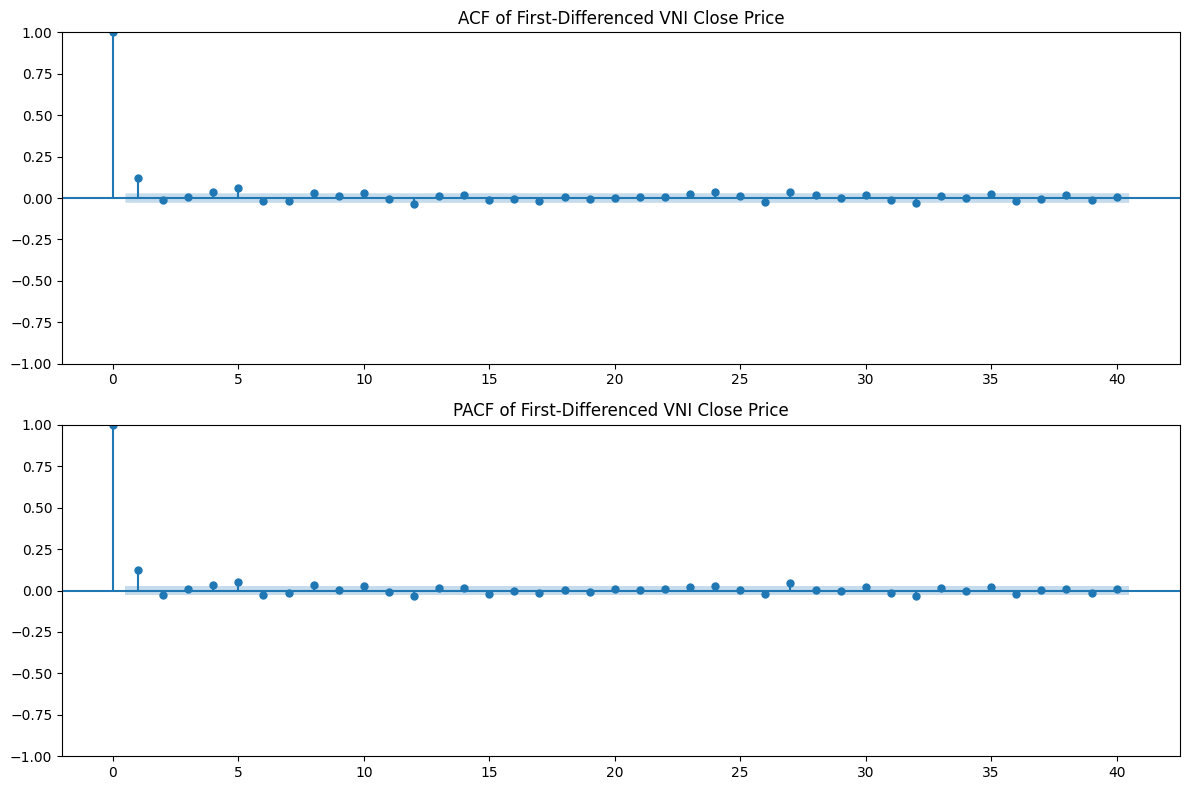

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Correlogram for the first-differenced Close price series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(close_price_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF of First-Differenced VNI Close Price')

plot_pacf(close_price_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF of First-Differenced VNI Close Price')

plt.tight_layout()
plt.savefig('plot/vni_correlogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
series = df.set_index('Date')['Close']

split_idx = int(len(series) * 0.8)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f'Train size: {len(train)} | Test size: {len(test)}')

# Baseline ARIMA order, easy to tune later
order = (5, 1, 0)
model = ARIMA(train, order=order)
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
mape = mean_absolute_percentage_error(test, pred) * 100

print('ARIMA order:', order)
print(f'RMSE: {rmse:.3f}')
print(f'MAE : {mae:.3f}')
print(f'MAPE: {mape:.3f}%')

Train size: 3846 | Test size: 962


c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA order: (5, 1, 0)
RMSE: 241.792
MAE : 165.434
MAPE: 11.635%


c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


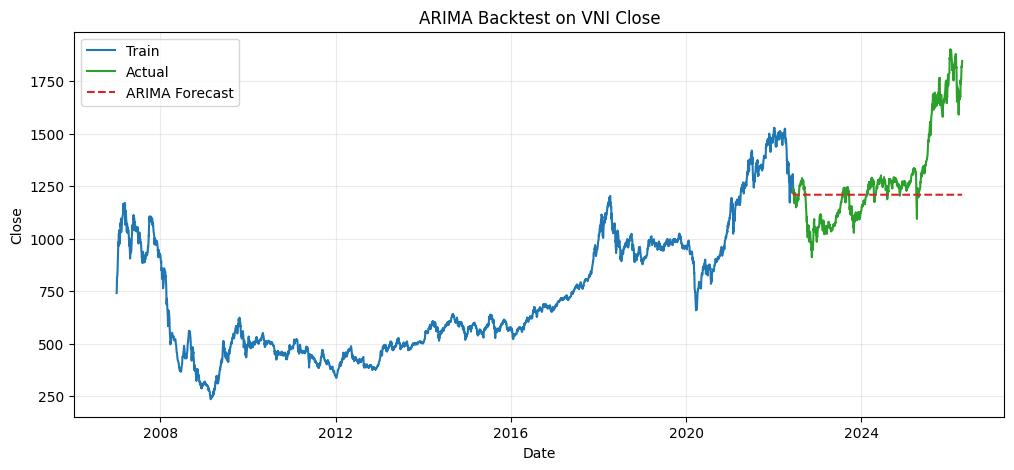

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train', color='tab:blue')
plt.plot(test.index, test, label='Actual', color='tab:green')
plt.plot(test.index, pred, label='ARIMA Forecast', color='tab:red', linestyle='--')
plt.title('ARIMA Backtest on VNI Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_arima_backtest.png', dpi=300, bbox_inches='tight')
plt.show()

c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Seri

,Date,ARIMA_Forecast
0,2026-04-22,1850.247465
1,2026-04-23,1851.340676
2,2026-04-24,1851.747270
3,2026-04-27,1853.018316
4,2026-04-28,1854.038418


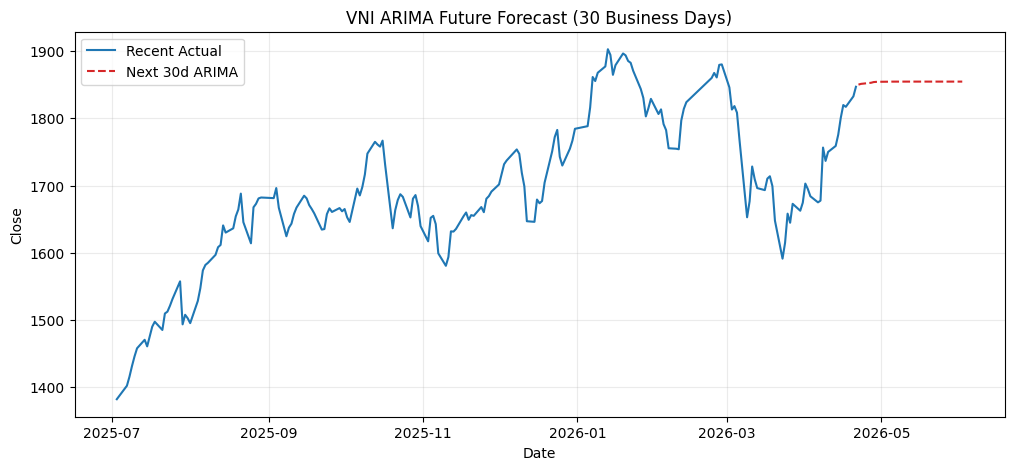

In [31]:
# Fit on full history and forecast next 30 business days
future_steps = 30
final_model = ARIMA(series, order=(5, 1, 0)).fit()
future_arima = final_model.forecast(steps=future_steps)
future_dates = pd.bdate_range(series.index[-1] + pd.offsets.BDay(1), periods=future_steps)

arima_fc_df = pd.DataFrame({'Date': future_dates, 'ARIMA_Forecast': future_arima.values})
display(arima_fc_df.head())

plt.figure(figsize=(12, 5))
plt.plot(series.index[-200:], series.values[-200:], label='Recent Actual', color='tab:blue')
plt.plot(arima_fc_df['Date'], arima_fc_df['ARIMA_Forecast'], label='Next 30d ARIMA', color='tab:red', linestyle='--')
plt.title('VNI ARIMA Future Forecast (30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_arima_future_forecast.png', dpi=300, bbox_inches='tight')
plt.show()


Epoch comparison (selected by lowest mape):



,Epochs,Train Loss,Validation Loss,Test RMSE,Test MAE,Test MAPE (%)
0,150,0.000401,0.003140,123.974282,93.955312,6.538378
1,100,0.000461,0.004473,140.379602,107.835392,7.524040
2,50,0.000488,0.004484,148.267761,113.250038,7.891542
3,40,0.000527,0.005415,168.124398,129.113901,9.015401
4,10,0.001271,0.006035,186.488580,140.138990,9.726125
5,20,0.000782,0.007654,184.109315,143.918782,10.094060
6,30,0.000643,0.008256,193.778795,153.619916,10.828185



Best epoch count: 150 (lowest mape = 6.538378)

Standalone LSTM results at selected epoch count:
Epochs: 150
RMSE  : 123.974
MAE   : 93.955
MAPE  : 6.538%


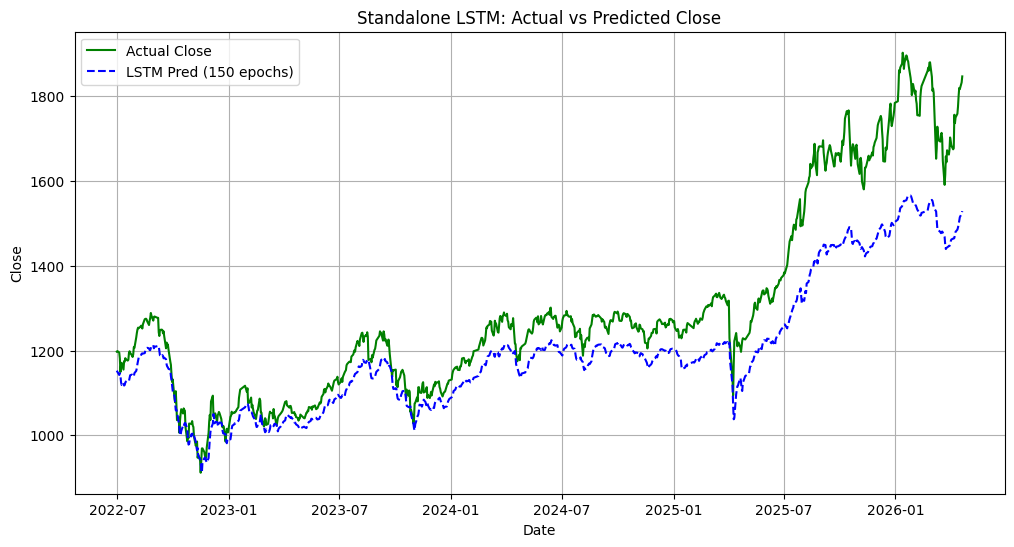

In [32]:
# Standalone LSTM: sweep epochs and evaluate predicting `Close` (multivariate inputs)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# Prepare data (use existing `df`)
data_lstm = df.copy()
date_col = 'Date'
if date_col in data_lstm.columns:
    data_lstm[date_col] = pd.to_datetime(data_lstm[date_col])
    data_lstm = data_lstm.sort_values(date_col).set_index(date_col)

features = ['Close', 'Volume', 'Open', 'High', 'Low']
data_lstm = data_lstm[features].ffill().bfill().astype(float)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_lstm.values)

time_step = 60

def create_dataset(dataset, step=1):
    X, y = [], []
    for i in range(len(dataset) - step):
        X.append(dataset[i:(i + step), :])
        y.append(dataset[i + step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled, time_step)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Chronological validation split inside the training set
val_size = max(1, int(len(X_train) * 0.1))
X_fit, X_val = X_train[:-val_size], X_train[-val_size:]
y_fit, y_val = y_train[:-val_size], y_train[-val_size:]


def build_model(input_shape):
    model = Sequential()
    model.add(LSTM(48, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.25))
    model.add(LSTM(24, return_sequences=False))
    model.add(Dropout(0.25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Try several epoch counts and choose the one with the lowest validation loss
epoch_candidates = [10, 20, 30, 40, 50, 100, 150]
results = []
best_epoch = None
best_mape = np.inf
best_model = None

for epoch_count in epoch_candidates:
    tf.keras.backend.clear_session()
    model_lstm = build_model((X_fit.shape[1], X_fit.shape[2]))
    history = model_lstm.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=epoch_count,
        batch_size=32,
        verbose=0,
        shuffle=False,
    )

    train_loss = float(history.history['loss'][-1])
    val_loss = float(history.history['val_loss'][-1])

    pred_scaled = model_lstm.predict(X_test, verbose=0)
    dummy_pred = np.zeros((len(pred_scaled), scaled.shape[1]))
    dummy_pred[:, 0] = pred_scaled[:, 0]
    pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]

    dummy_y = np.zeros((len(y_test), scaled.shape[1]))
    dummy_y[:, 0] = y_test
    y_inv = scaler.inverse_transform(dummy_y)[:, 0]

    test_rmse = np.sqrt(mean_squared_error(y_inv, pred_inv))
    test_mae = mean_absolute_error(y_inv, pred_inv)
    test_mape = mean_absolute_percentage_error(y_inv, pred_inv) * 100

    results.append({
        'Epochs': epoch_count,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test MAPE (%)': test_mape,
    })

    if test_mape < best_mape:
        best_mape = test_mape
        best_epoch = epoch_count
        best_model = model_lstm
        best_pred_inv = pred_inv
        best_y_inv = y_inv

results_df = pd.DataFrame(results).sort_values('Test MAPE (%)').reset_index(drop=True)
print('\nEpoch comparison (selected by lowest mape):\n')
display(results_df)
print(f"\nBest epoch count: {best_epoch} (lowest mape = {best_mape:.6f})")

# Final metrics for the selected epoch count
rmse = np.sqrt(mean_squared_error(best_y_inv, best_pred_inv))
mae = mean_absolute_error(best_y_inv, best_pred_inv)
mape = mean_absolute_percentage_error(best_y_inv, best_pred_inv) * 100

print('\nStandalone LSTM results at selected epoch count:')
print(f'Epochs: {best_epoch}')
print(f'RMSE  : {rmse:.3f}')
print(f'MAE   : {mae:.3f}')
print(f'MAPE  : {mape:.3f}%')

# Plot
plt.figure(figsize=(12, 6))
idx = data_lstm.index[-len(best_y_inv):]
plt.plot(idx, best_y_inv, label='Actual Close', color='green')
plt.plot(idx, best_pred_inv, label=f'LSTM Pred ({best_epoch} epochs)', color='blue', linestyle='--')
plt.title('Standalone LSTM: Actual vs Predicted Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.savefig('plot/vni_lstm_future_forecast.png', dpi=300, bbox_inches='tight')
plt.show()


=== GIAI DOAN 1: CHUAN BI DU LIEU ===
So dong Train: 3846 | So dong Test: 962

=== GIAI DOAN 2: ARIMA WALK-FORWARD (NO FUTURE LEAK) ===


c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Series-Forecasting-Apple-Stock-Price-Using-SARIMA-Prophet\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tuan Minh Hoang\Time-Seri


=== GIAI DOAN 3: LSTM HOC PHAN DU ===
Dang huan luyen LSTM tren phan du...
Epoch da dung: 30
Residual weight (calibrated): 0.200

=== GIAI DOAN 4: HYBRID WALK-FORWARD TEST ===

=== HYBRID WALK-FORWARD TEST RESULTS (ARIMA + LSTM) ===
ARIMA order: (5, 1, 0)
RMSE : 20.005
MAE  : 14.067
MAPE : 1.055%


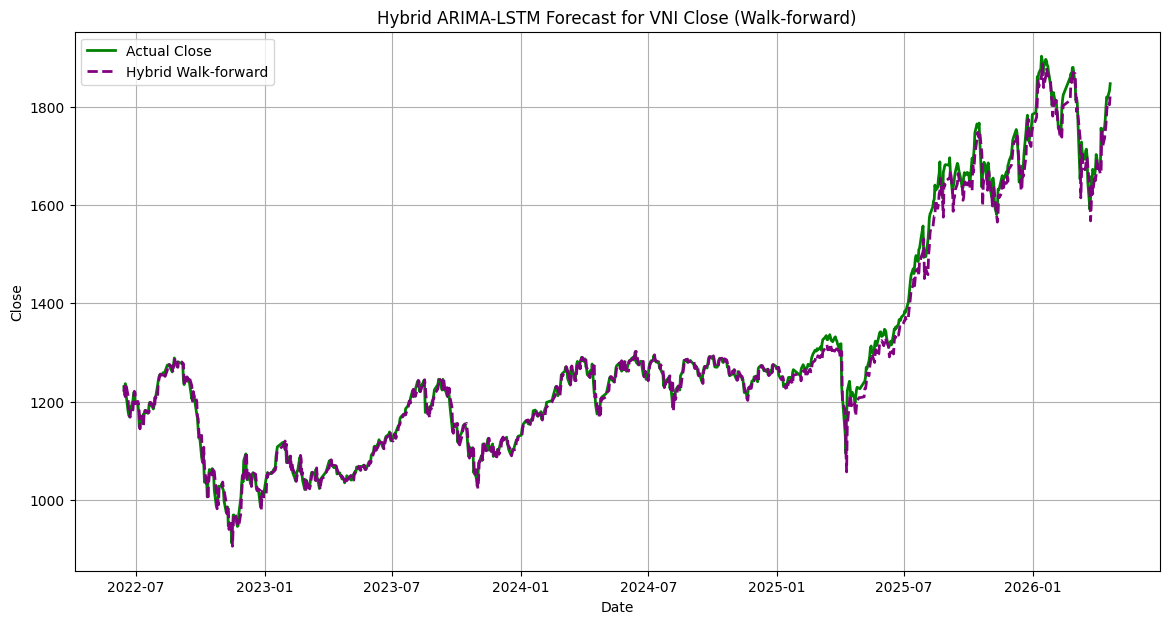

In [33]:
# %pip install tensorflow scikit-learn
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf


np.random.seed(42)
tf.random.set_seed(42)


print('=== GIAI DOAN 1: CHUAN BI DU LIEU ===')

hybrid_df = df.copy()


# Ensure all features are numeric
for c in ['Open', 'High', 'Low', 'Close']:
    hybrid_df[c] = hybrid_df[c].apply(parse_number)
hybrid_df['Volume'] = hybrid_df['Volume'].apply(parse_volume)


hybrid_df = hybrid_df.sort_values('Date').dropna(subset=['Close']).reset_index(drop=True)
feature_cols = ['Volume', 'Open', 'High', 'Low']
hybrid_df[feature_cols] = hybrid_df[feature_cols].ffill().bfill()
hybrid_df = hybrid_df.set_index('Date')


train_size = int(len(hybrid_df) * 0.8)
train_df = hybrid_df.iloc[:train_size].copy()
test_df = hybrid_df.iloc[train_size:].copy()


train_price = train_df['Close'].astype(float)
test_price = test_df['Close'].astype(float)
print(f'So dong Train: {len(train_df)} | So dong Test: {len(test_df)}')


print('\n=== GIAI DOAN 2: ARIMA WALK-FORWARD (NO FUTURE LEAK) ===')

arima_order = (5, 1, 0)
arima_model = ARIMA(train_price, order=arima_order)
arima_result = arima_model.fit()


# Train residuals
train_df['ARIMA_Pred'] = arima_result.fittedvalues
train_df['Residuals'] = train_df['Close'] - train_df['ARIMA_Pred']
train_resid_df = train_df.dropna(subset=['Residuals']).copy()


# Strict one-step walk-forward: forecast t using data up to t-1, then update with actual y_t
rolling_result = arima_result
arima_test_preds = []
for y_t in test_price.values:
    forecast_one = rolling_result.forecast(steps=1)
    next_pred = float(forecast_one.iloc[0])
    arima_test_preds.append(next_pred)
    rolling_result = rolling_result.append([y_t], refit=False)
arima_test_preds = np.array(arima_test_preds)


print('\n=== GIAI DOAN 3: LSTM HOC PHAN DU ===')

features = ['Residuals', 'Volume', 'Open', 'High', 'Low']
train_feat = train_resid_df[features].values


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_feat)


time_step = 60

def create_dataset(dataset, step=1):
    X, y = [], []
    for i in range(len(dataset) - step):
        X.append(dataset[i:(i + step), :])
        y.append(dataset[i + step, 0])
    return np.array(X), np.array(y)


X_train_full, y_train_full = create_dataset(scaled_train, time_step)
val_size = max(1, int(len(X_train_full) * 0.1))
X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]
X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]


model = Sequential()
model.add(LSTM(units=48, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.25))
model.add(LSTM(units=24, return_sequences=False))
model.add(Dropout(0.25))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')


callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
]


print('Dang huan luyen LSTM tren phan du...')
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=0,
    shuffle=False,
    callbacks=callbacks
)
print(f"Epoch da dung: {len(history.history['loss'])}")


# Calibrate residual correction strength on validation (train-only)
val_scaled_pred = model.predict(X_val, verbose=0)
dummy_val = np.zeros((len(val_scaled_pred), len(features)))
dummy_val[:, 0] = val_scaled_pred[:, 0]
val_res_pred = scaler.inverse_transform(dummy_val)[:, 0]


dummy_y_val = np.zeros((len(y_val), len(features)))
dummy_y_val[:, 0] = y_val
val_res_true = scaler.inverse_transform(dummy_y_val)[:, 0]


den = float(np.dot(val_res_pred, val_res_pred))
if den > 0:
    residual_weight = float(np.dot(val_res_true, val_res_pred) / den)
else:
    residual_weight = 1.0
residual_weight = float(np.clip(residual_weight, 0.2, 1.2))
print(f'Residual weight (calibrated): {residual_weight:.3f}')


print('\n=== GIAI DOAN 4: HYBRID WALK-FORWARD TEST ===')

# Residual forecast each day, then update window with realized residual (available after day close)
window_scaled = scaled_train[-time_step:, :].copy()
test_exog = test_df[['Volume', 'Open', 'High', 'Low']].values
actual_test_price = test_price.values


final_hybrid_pred = []


for i in range(len(test_df)):
    x_input = window_scaled.reshape(1, time_step, len(features))
    pred_res_scaled = model.predict(x_input, verbose=0)[0, 0]

    dummy = np.zeros((1, len(features)))
    dummy[0, 0] = pred_res_scaled
    pred_residual = scaler.inverse_transform(dummy)[0, 0]

    yhat = arima_test_preds[i] + residual_weight * pred_residual
    final_hybrid_pred.append(yhat)

    # Update window with realized residual at current step (strictly past info for next step)
    realized_residual = actual_test_price[i] - arima_test_preds[i]
    next_row_raw = np.array([
        realized_residual,
        test_exog[i, 0],
        test_exog[i, 1],
        test_exog[i, 2],
        test_exog[i, 3]
    ], dtype=float).reshape(1, -1)
    next_row_scaled = scaler.transform(next_row_raw)
    window_scaled = np.vstack([window_scaled[1:], next_row_scaled])


final_hybrid_pred = np.array(final_hybrid_pred)
test_dates = test_df.index


valid_mask = np.isfinite(final_hybrid_pred) & np.isfinite(actual_test_price)
final_hybrid_pred = final_hybrid_pred[valid_mask]
actual_test_price = actual_test_price[valid_mask]
test_dates = test_dates[valid_mask]


rmse = np.sqrt(mean_squared_error(actual_test_price, final_hybrid_pred))
mae = mean_absolute_error(actual_test_price, final_hybrid_pred)
mape = mean_absolute_percentage_error(actual_test_price, final_hybrid_pred) * 100


print('\n=== HYBRID WALK-FORWARD TEST RESULTS (ARIMA + LSTM) ===')
print(f'ARIMA order: {arima_order}')
print(f'RMSE : {rmse:.3f}')
print(f'MAE  : {mae:.3f}')
print(f'MAPE : {mape:.3f}%')


plt.figure(figsize=(14, 7))
plt.plot(test_dates, actual_test_price, label='Actual Close', color='green', linewidth=2)
plt.plot(test_dates, final_hybrid_pred, label='Hybrid Walk-forward', color='purple', linestyle='--', linewidth=2)
plt.title('Hybrid ARIMA-LSTM Forecast for VNI Close (Walk-forward)')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.savefig('plot/vni_hybrid_walk_forward.png', dpi=300, bbox_inches='tight')
plt.show()